In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
career = pd.read_csv("/content/drive/MyDrive/career_guidance_dataset.csv")
career.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Student_ID                          1000 non-null   object 
 1   Age                                 1000 non-null   int64  
 2   Gender                              1000 non-null   object 
 3   Field_of_Study                      1000 non-null   object 
 4   Year_of_Study                       1000 non-null   int64  
 5   University_Location                 1000 non-null   object 
 6   GPA                                 1000 non-null   float64
 7   Relevant_Coursework                 1000 non-null   int64  
 8   Prior_Employment                    1000 non-null   int64  
 9   Employment_Type                     1000 non-null   object 
 10  Entrepreneurial_Experience          1000 non-null   int64  
 11  Startup_Participation               1000 non

In [ ]:
#here's a function to find correlation
def find_correlation(career_numeric):
  # computing standard correlation coefficient
  corr_matrix = career_numeric.corr()
  # fetch and return attribute correlates
  # with the median housing value
  return corr_matrix["median_house_value"].sort_values(
    ascending=False)

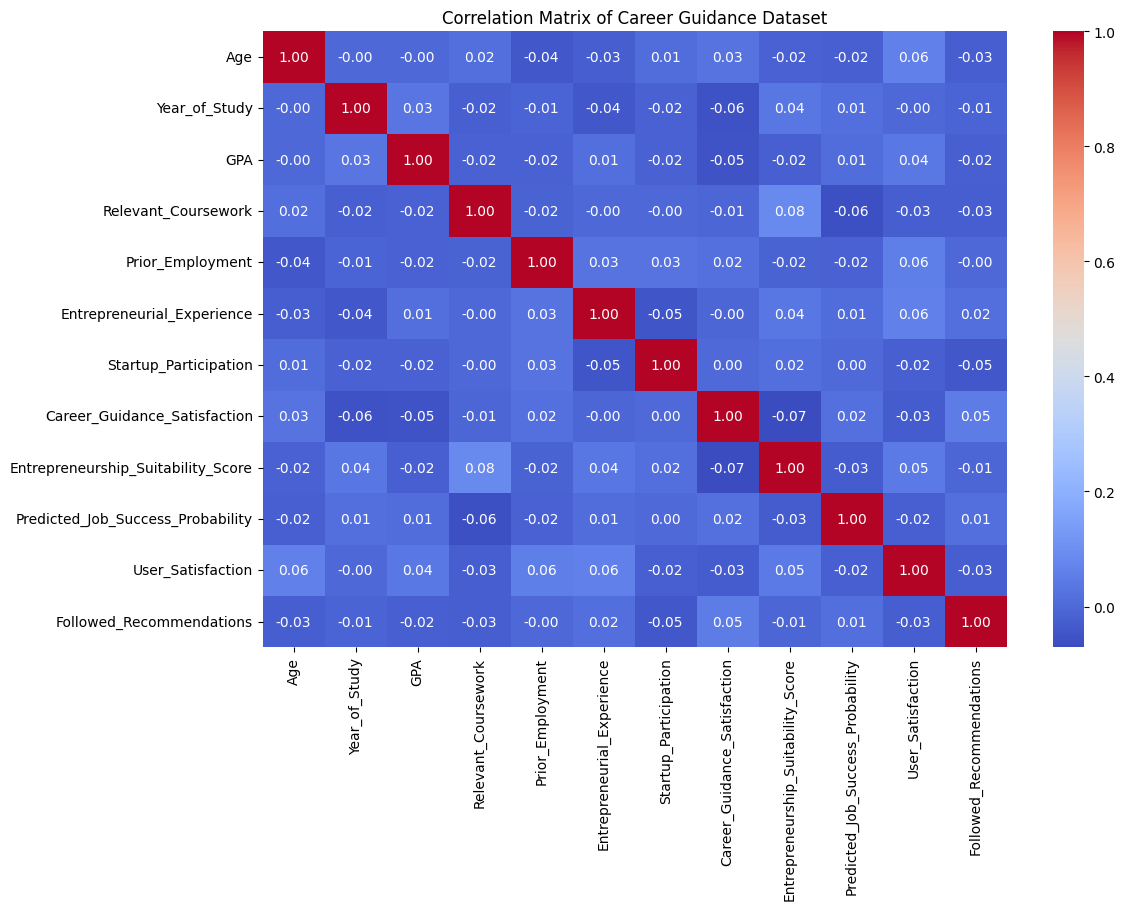

Correlations with Predicted Job Success Probability:


,Predicted_Job_Success_Probability
Predicted_Job_Success_Probability,1.000000
Career_Guidance_Satisfaction,0.017273
Year_of_Study,0.014664
Followed_Recommendations,0.014184
Entrepreneurial_Experience,0.011196
GPA,0.009987
Startup_Participation,0.001123
Prior_Employment,-0.017814
User_Satisfaction,-0.021196
Age,-0.024853


In [ ]:
# Selecting only numeric columns from the career dataset
career_numeric = career.select_dtypes(include=['number'])

# Calculating the correlation matrix
corr_matrix = career_numeric.corr()

# Displaying the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Career Guidance Dataset')
plt.show()

# Display the correlations specifically for Job Success Probability
if 'Predicted_Job_Success_Probability' in corr_matrix.columns:
    print("Correlations with Predicted Job Success Probability:")
    display(corr_matrix['Predicted_Job_Success_Probability'].sort_values(ascending=False))

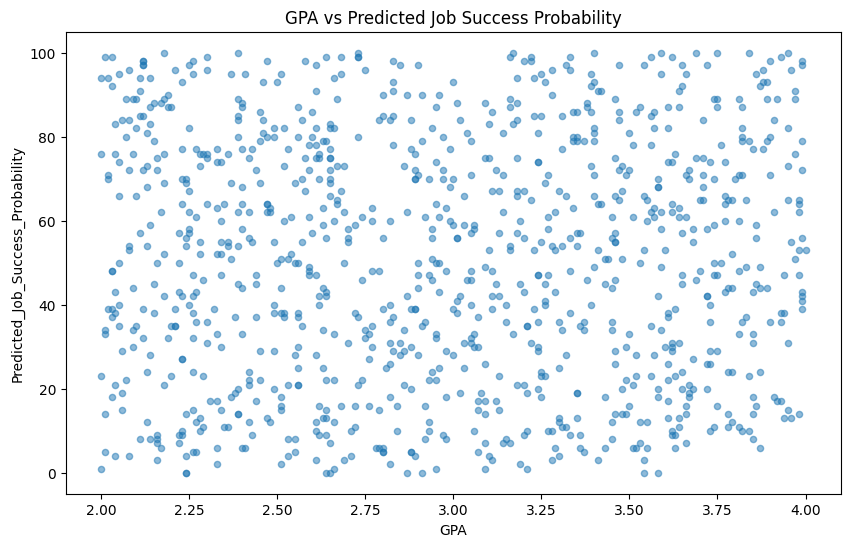

In [ ]:
# scatter plot diagram using existing columns from the career dataset
# Plotting GPA vs Predicted Job Success Probability
career.plot(kind='scatter',
             x='GPA',
             y='Predicted_Job_Success_Probability',
             alpha=0.5,
             figsize=(10, 6))
import matplotlib.pyplot as plt
plt.title('GPA vs Predicted Job Success Probability')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Defining the features (X) and target (Y) from the dataset
# We'll use numeric columns for X and the success probability for Y
X = career_numeric.drop('Predicted_Job_Success_Probability', axis=1)
Y = career_numeric['Predicted_Job_Success_Probability']

# Split data into 80% train and 20% test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Data split complete.")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Data split complete.
Training set size: 800
Testing set size: 200


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
# linear regression model for best fit
# Fit linear regression
model = LinearRegression()
model.fit(X_train, Y_train)

# Predict on test set
Y_pred = model.predict(X_test)

# Calculate MAE and RMSE
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 24.5462
RMSE: 28.7905


#Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Retraining Random Forest with the correct encoded features (X_train from the cleaned dataset)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
Y_pred_rf = rf.predict(X_test)

# Calculate MAE and RMSE
mae_rf = mean_absolute_error(y_test, Y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, Y_pred_rf))

print(f"Updated Random Forest MAE: {mae_rf:.4f}")
print(f"Updated Random Forest RMSE: {rmse_rf:.4f}")

Updated Random Forest MAE: 24.9644
Updated Random Forest RMSE: 29.2071


#Polynomial Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

In [ ]:
# Split data into 80% train and 20% test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Transform the features to include polynomial terms (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
# Train the Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, Y_train)

LinearRegression()

In [ ]:
# Predict on the test set
Y_pred_poly = poly_model.predict(X_test_poly)

# Calculate performance metrics
poly_mae = mean_absolute_error(Y_test, Y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_poly))
poly_r2 = poly_model.score(X_test_poly, Y_test)

# Print the results
print(f"Polynomial Regression MAE: {poly_mae:.4f}")
print(f"Polynomial Regression RMSE: {poly_rmse:.4f}")
print(f"Polynomial Regression R2 Score: {poly_r2:.4f}")

Polynomial Regression MAE: 25.3339
Polynomial Regression RMSE: 29.9746
Polynomial Regression R2 Score: -0.1110


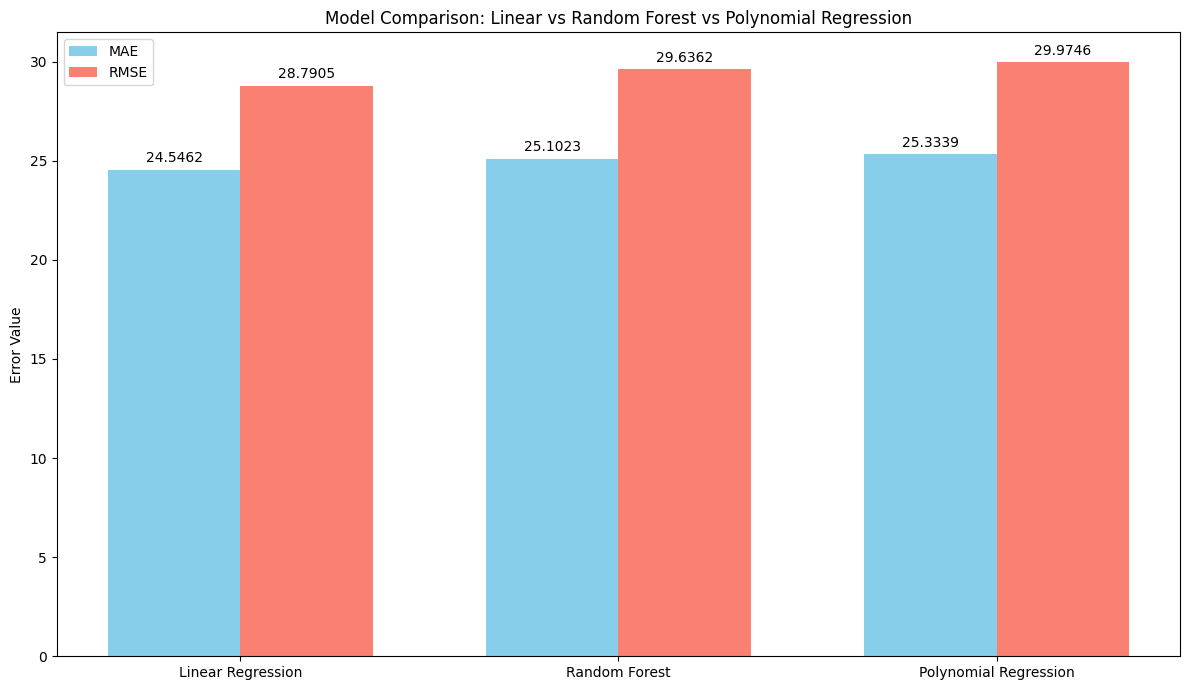

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics data for comparison of all 3 models
models = ['Linear Regression', 'Random Forest', 'Polynomial Regression']
# Values retrieved from previous cell execution results
mae_values = [24.5462, 25.1023, 25.3339]
rmse_values = [28.7905, 29.6362, 29.9746]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, mae_values, width, label='MAE', color='skyblue')
rects2 = ax.bar(x + width/2, rmse_values, width, label='RMSE', color='salmon')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Error Value')
ax.set_title('Model Comparison: Linear vs Random Forest vs Polynomial Regression')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()

In [ ]:
# Step 4: Check and handle missing values
print("Missing values in each column:")
print(career.isnull().sum(), "\n")

Missing values in each column:
Student_ID                            0
Age                                   0
Gender                                0
Field_of_Study                        0
Year_of_Study                         0
University_Location                   0
GPA                                   0
Relevant_Coursework                   0
Prior_Employment                      0
Employment_Type                       0
Entrepreneurial_Experience            0
Startup_Participation                 0
Career_Interests                      0
Entrepreneurial_Aspirations           0
Career_Guidance_Satisfaction          0
Recommended_Career_Path               0
Entrepreneurship_Suitability_Score    0
Top_Recommended_Industries            0
Predicted_Job_Success_Probability     0
User_Satisfaction                     0
Followed_Recommendations              0
Employment_Status_Post_Graduation     0
dtype: int64 



In [ ]:
# Step 5: Handle categorical columns present in the career dataset
# Identify categorical columns (object type)
cat_cols = career.select_dtypes(include=['object']).columns.tolist()

# We'll exclude 'Student_ID' as it is a unique identifier
if 'Student_ID' in cat_cols:
    cat_cols.remove('Student_ID')

print(f"Encoding categorical columns: {cat_cols}")

# Convert categorical values into dummy (0/1) columns
career = pd.get_dummies(career, columns=cat_cols, drop_first=True)

# Display the first few rows to see the new dummy columns
career.head()

Encoding categorical columns: ['Gender', 'Field_of_Study', 'University_Location', 'Employment_Type', 'Career_Interests', 'Entrepreneurial_Aspirations', 'Recommended_Career_Path', 'Top_Recommended_Industries', 'Employment_Status_Post_Graduation']


,Student_ID,Age,Year_of_Study,GPA,Relevant_Coursework,Prior_Employment,Entrepreneurial_Experience,Startup_Participation,Career_Guidance_Satisfaction,Entrepreneurship_Suitability_Score,...,Recommended_Career_Path_Design,Recommended_Career_Path_Finance,Recommended_Career_Path_Healthcare,Recommended_Career_Path_Tech,Top_Recommended_Industries_Education,Top_Recommended_Industries_Finance,Top_Recommended_Industries_Healthcare,Top_Recommended_Industries_Tech,Employment_Status_Post_Graduation_Self-employed,Employment_Status_Post_Graduation_Unemployed
0,S0001,24,4,3.64,0,1,1,1,7,11,...,False,False,True,False,False,False,False,True,False,True
1,S0002,21,5,2.88,0,1,0,1,1,34,...,True,False,False,False,False,False,True,False,True,False
2,S0003,28,3,2.26,1,1,0,1,6,69,...,False,False,False,True,False,False,False,True,False,False
3,S0004,25,5,2.76,1,0,1,1,6,71,...,False,True,False,False,False,True,False,False,False,True
4,S0005,22,2,3.24,1,1,1,1,5,20,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
print("Data after encoding categorical feature:")
print(career.head(), "\n")

Data after encoding categorical feature:
  Student_ID  Age  Year_of_Study   GPA  Relevant_Coursework  Prior_Employment  \
0      S0001   24              4  3.64                    0                 1   
1      S0002   21              5  2.88                    0                 1   
2      S0003   28              3  2.26                    1                 1   
3      S0004   25              5  2.76                    1                 0   
4      S0005   22              2  3.24                    1                 1   

   Entrepreneurial_Experience  Startup_Participation  \
0                           1                      1   
1                           0                      1   
2                           0                      1   
3                           1                      1   
4                           1                      1   

   Career_Guidance_Satisfaction  Entrepreneurship_Suitability_Score  ...  \
0                             7                            

In [ ]:
print(career.isnull().sum(), "\n")

Student_ID                                         0
Age                                                0
Year_of_Study                                      0
GPA                                                0
Relevant_Coursework                                0
Prior_Employment                                   0
Entrepreneurial_Experience                         0
Startup_Participation                              0
Career_Guidance_Satisfaction                       0
Entrepreneurship_Suitability_Score                 0
Predicted_Job_Success_Probability                  0
User_Satisfaction                                  0
Followed_Recommendations                           0
Gender_Male                                        0
Gender_Other                                       0
Field_of_Study_Business                            0
Field_of_Study_Engineering                         0
Field_of_Study_Law                                 0
Field_of_Study_Science                        

In [ ]:
# Step 6: Separate features (X) and target (y)
# We drop the target column and the unique identifier Student_ID
X = career.drop(["Predicted_Job_Success_Probability", "Student_ID"], axis=1)
y = career["Predicted_Job_Success_Probability"]

In [ ]:
# Step 7: Split the dataset into training and test sets using the cleaned X and y
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (800, 37)
Test set shape: (200, 37)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 8: Feature scaling (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step 9: Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Step 10: Make predictions
# Now that X_test_scaled is cleaned, this should succeed
y_pred = model.predict(X_test_scaled)

# Step 11: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

Model Performance:
Mean Squared Error: 851.14
R2 Score: -0.0525


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 24.7824
RMSE: 29.1743


Model Coefficients:
                                            Feature  Coefficient
0                                               Age    -1.067869
1                                     Year_of_Study     1.338898
2                                               GPA     0.125614
3                               Relevant_Coursework    -1.814669
4                                  Prior_Employment     0.523753
5                        Entrepreneurial_Experience     0.692056
6                             Startup_Participation     0.186982
7                      Career_Guidance_Satisfaction     0.601150
8                Entrepreneurship_Suitability_Score    -0.449467
9                                 User_Satisfaction    -0.446232
10                         Followed_Recommendations     0.056806
11                                      Gender_Male    -1.641189
12                                     Gender_Other    -0.383725
13                          Field_of_Study_Business    -0.746866
14   

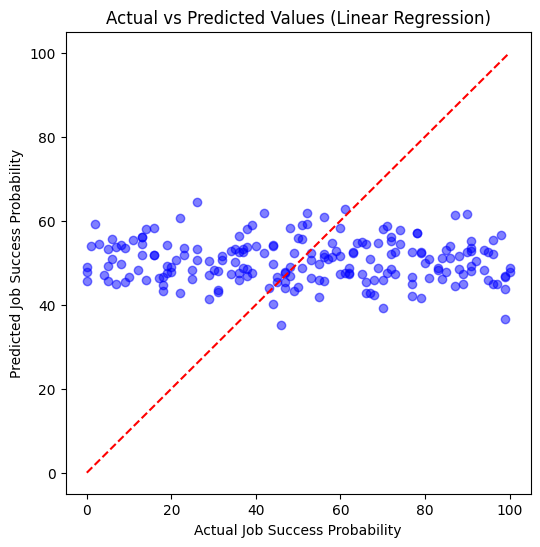

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 12: Display model coefficients
# The features used for the model are in the variable 'X' (already defined in previous cells)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("Model Coefficients:")
print(coefficients, "\n")

# Step 13: Visualize actual vs predicted values
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Job Success Probability")
plt.ylabel("Predicted Job Success Probability")
plt.title("Actual vs Predicted Values (Linear Regression)")
plt.show()

In [ ]:
# The original 'Field_of_Study' column was transformed during one-hot encoding.
# Here are the columns currently in the 'career' dataframe:
print("Current columns in 'career' dataframe:")
print(career.columns.tolist())

# To see the original categories, we can look at the list of categorical columns we identified earlier:
print(f"\nOriginal categorical columns identified: {cat_cols}")

Current columns in 'career' dataframe:
['Student_ID', 'Age', 'Year_of_Study', 'GPA', 'Relevant_Coursework', 'Prior_Employment', 'Entrepreneurial_Experience', 'Startup_Participation', 'Career_Guidance_Satisfaction', 'Entrepreneurship_Suitability_Score', 'Predicted_Job_Success_Probability', 'User_Satisfaction', 'Followed_Recommendations', 'Gender_Male', 'Gender_Other', 'Field_of_Study_Business', 'Field_of_Study_Engineering', 'Field_of_Study_Law', 'Field_of_Study_Science', 'University_Location_Region B', 'University_Location_Region C', 'Employment_Type_Internship', 'Employment_Type_Part-time', 'Career_Interests_Design', 'Career_Interests_Finance', 'Career_Interests_Healthcare', 'Career_Interests_Tech', 'Entrepreneurial_Aspirations_Low', 'Entrepreneurial_Aspirations_Medium', 'Recommended_Career_Path_Design', 'Recommended_Career_Path_Finance', 'Recommended_Career_Path_Healthcare', 'Recommended_Career_Path_Tech', 'Top_Recommended_Industries_Education', 'Top_Recommended_Industries_Finance', '

In [ ]:
# Separate features (X) and target (y) using the correct dataset and column names
# We drop 'Predicted_Job_Success_Probability' (target) and 'Student_ID' (identifier)
y = career["Predicted_Job_Success_Probability"]
X = career.drop(["Predicted_Job_Success_Probability", "Student_ID"], axis=1)

# Optional: check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 37)
y shape: (1000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
#Train Linear Regression on full dataset
model = LinearRegression()
model.fit(X_scaled, y)

LinearRegression()

In [ ]:
# Randomly select 5 instances
np.random.seed(42)
random_indices = np.random.choice(len(X_scaled), 5, replace=False)

X_sample = X_scaled[random_indices]
y_sample = y.iloc[random_indices]

In [ ]:
# Predict
y_pred = model.predict(X_sample)

# Compare predictions vs actual
for i in range(5):
    print(f"Predicted: {y_pred[i]:.2f} | Actual: {y_sample.iloc[i]:.2f}")

Predicted: 49.84 | Actual: 79.00
Predicted: 48.24 | Actual: 61.00
Predicted: 51.90 | Actual: 85.00
Predicted: 53.39 | Actual: 13.00
Predicted: 53.50 | Actual: 29.00


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict on the whole dataset
y_pred_full = model.predict(X_scaled)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred_full))

# Calculate MAE
mae = mean_absolute_error(y, y_pred_full)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 28.277277329397705
MAE: 24.2700988796441


In [ ]:
from sklearn.tree import DecisionTreeRegressor
# Train Decision Tree Regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_scaled, y)

DecisionTreeRegressor(random_state=42)

In [ ]:
# Evaluate 5 random instances
np.random.seed(42)
random_indices = np.random.choice(len(X_scaled), 5, replace=False)

X_sample = X_scaled[random_indices]
y_sample = y.iloc[random_indices]
y_pred_sample = tree_model.predict(X_sample)

print("\nSample Predictions:")
for i in range(5):
    print(f"Predicted: {y_pred_sample[i]:.2f} | Actual: {y_sample.iloc[i]:.2f}")


Sample Predictions:
Predicted: 79.00 | Actual: 79.00
Predicted: 61.00 | Actual: 61.00
Predicted: 85.00 | Actual: 85.00
Predicted: 13.00 | Actual: 13.00
Predicted: 29.00 | Actual: 29.00


In [ ]:
# Predict on full dataset
y_pred_full = tree_model.predict(X_scaled)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred_full))

# Calculate MAE
mae = mean_absolute_error(y, y_pred_full)

print("Training RMSE:", rmse)
print("Training MAE:", mae)

Training RMSE: 0.0
Training MAE: 0.0


In [ ]:
#import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize the KNN Regressor (since we are predicting success probability)
knn = KNeighborsRegressor(n_neighbors=5)

# Train the KNN model using the scaled training data created in earlier cells
knn.fit(X_train_scaled, Y_train)

KNeighborsRegressor()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Fix: Use the correct scaled test data
y_pred = knn.predict(X_test_scaled)

# For regression, we use error metrics instead of Accuracy/Precision
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))

print(f"KNN Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

KNN Regressor Performance:
Mean Absolute Error (MAE): 26.0550
Root Mean Squared Error (RMSE): 31.5074


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Using DecisionTreeRegressor for continuous target 'Predicted_Job_Success_Probability'
dt_regressor = DecisionTreeRegressor(random_state=42)

# Use correct variable names: X_train_scaled and y_train
dt_regressor.fit(X_train_scaled, y_train)

# Use X_test_scaled for prediction
y_pred_dt = dt_regressor.predict(X_test_scaled)

# Calculate metrics
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Performance:")
print(f"RMSE: {dt_rmse:.4f}")
print(f"MAE: {dt_mae:.4f}")
print(f"R2 Score: {dt_r2:.4f}")

Decision Tree Regressor Performance:
RMSE: 41.7504
MAE: 34.9200
R2 Score: -1.1554


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize Decision Tree Regressor for continuous target
dt_model = DecisionTreeRegressor(random_state=42)

# Use existing scaled data and target variables
dt_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Results:")
print(f"MAE: {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R2 Score: {r2_dt:.4f}")

Decision Tree Regressor Results:
MAE: 34.9200
RMSE: 41.7504
R2 Score: -1.1554


#Regularization

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

ridge = Ridge(alpha=10.0)
lasso = Lasso(alpha=100)
elastic = ElasticNet(alpha=10, l1_ratio=0.5)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)

ElasticNet(alpha=10)

In [ ]:
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_elastic = elastic.predict(X_test_scaled)

ridge_score_r = r2_score(y_test, y_pred_ridge)
lasso_score_r = r2_score(y_test, y_pred_lasso)
elastic_score_r = r2_score(y_test, y_pred_elastic)

import math
ridge_score = math.sqrt(mean_squared_error(y_test, y_pred_ridge))
lasso_score = math.sqrt(mean_squared_error(y_test, y_pred_lasso))
elastic_score = math.sqrt(mean_squared_error(y_test, y_pred_elastic))

In [ ]:
lasso_score_r

-0.0012180671707135993

In [ ]:
models = ["Ridge", "Lasso", "ElasticNet"]
scores = [ridge_score, lasso_score, elastic_score]
scores

[29.152974956156548, 28.4550422816414, 28.4550422816414]

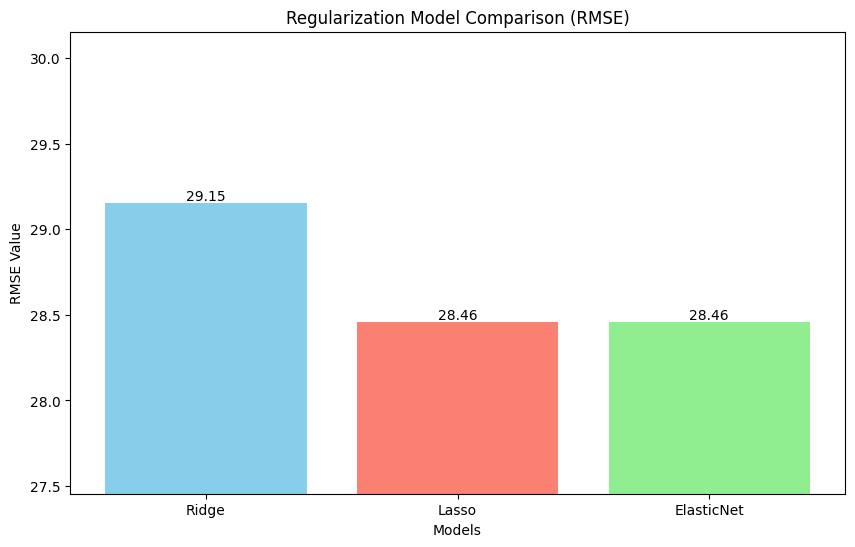

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(models, scores, color=['skyblue', 'salmon', 'lightgreen'])
plt.title("Regularization Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE Value")
# Adjusted y-limit to fit the actual scores (around 28-30)
plt.ylim(min(scores) - 1, max(scores) + 1)
for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.2f}', ha='center', va='bottom')
plt.show()

#K-fold Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Set up K-Fold
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Cross-validation for MAE
mae_scores = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

# Cross-validation for RMSE
rmse_scores = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')

# Print results for each fold
print(f"K-Fold Cross-Validation Results (k={k}):\n")
for i in range(k):
    print(f"Fold {i+1}: MAE = {mae_scores[i]:.4f}, RMSE = {rmse_scores[i]:.4f}")

print(f"\nAverage MAE: {np.mean(mae_scores):.4f}")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")

K-Fold Cross-Validation Results (k=5):

Fold 1: MAE = 23.4543, RMSE = 27.3369
Fold 2: MAE = 25.3072, RMSE = 29.7877
Fold 3: MAE = 26.4316, RMSE = 30.5082
Fold 4: MAE = 24.3878, RMSE = 28.4736
Fold 5: MAE = 27.6050, RMSE = 31.6777

Average MAE: 25.4372
Average RMSE: 29.5568


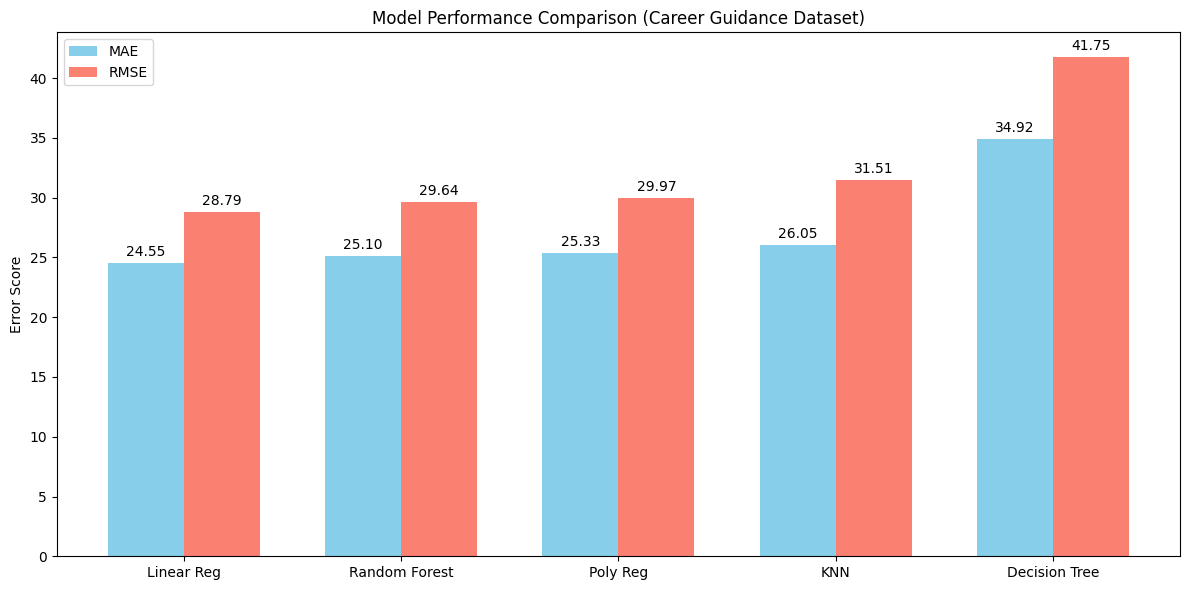

Summary Table (Sorted by Lowest Error):


,Model,MAE,RMSE
0,Linear Reg,24.5462,28.7905
1,Random Forest,25.1023,29.6362
2,Poly Reg,25.3339,29.9746
3,KNN,26.0550,31.5074
4,Decision Tree,34.9200,41.7504


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Consolidating metrics from the various model runs (80/20 Split)
model_names = ['Linear Reg', 'Random Forest', 'Poly Reg', 'KNN', 'Decision Tree']

# MAE values from previous cell executions
mae_scores = [24.5462, 25.1023, 25.3339, 26.0550, 34.9200]
# RMSE values from previous cell executions
rmse_scores = [28.7905, 29.6362, 29.9746, 31.5074, 41.7504]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, mae_scores, width, label='MAE', color='skyblue')
rects2 = ax.bar(x + width/2, rmse_scores, width, label='RMSE', color='salmon')

ax.set_ylabel('Error Score')
ax.set_title('Model Performance Comparison (Career Guidance Dataset)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

# Add labels on top of bars
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

fig.tight_layout()
plt.show()

print("Summary Table (Sorted by Lowest Error):")
results_df = pd.DataFrame({
    'Model': model_names,
    'MAE': mae_scores,
    'RMSE': rmse_scores
}).sort_values(by='MAE')
display(results_df)

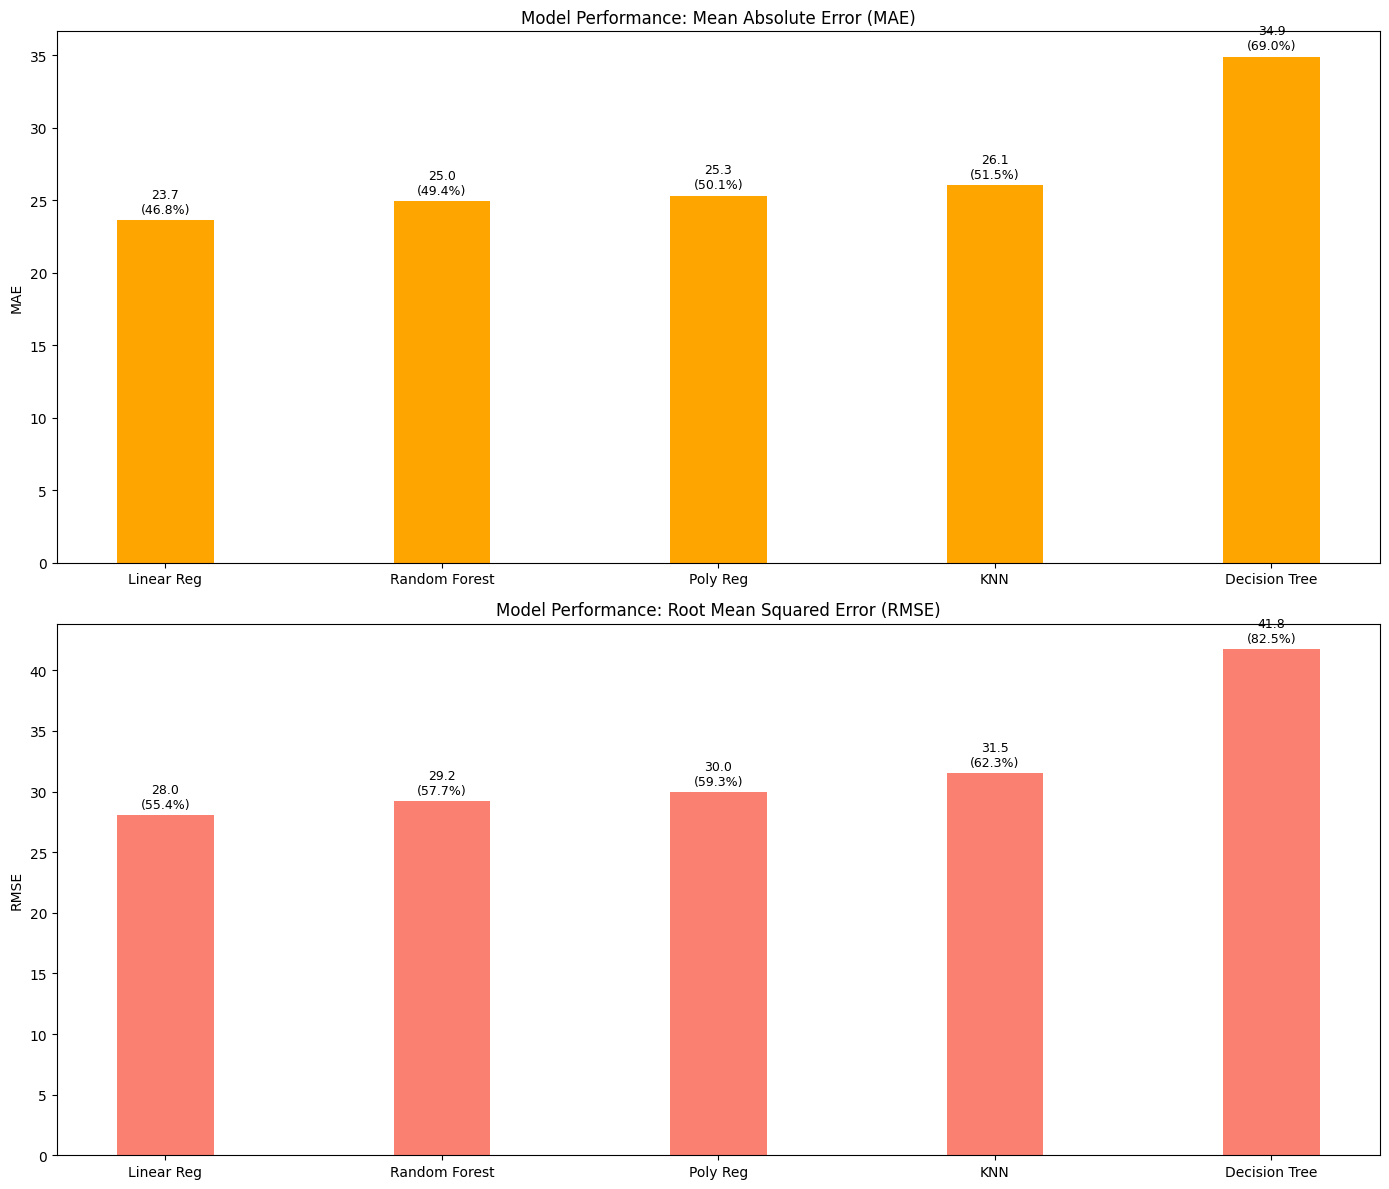

,Model,Test MAE,Test RMSE,MAE %,RMSE %
0,Linear Reg,23.654516,28.028268,46.765615,55.412641
1,Random Forest,24.964400,29.207057,49.355292,57.743140
2,Poly Reg,25.333871,29.974588,50.085746,59.260567
3,KNN,26.055000,31.507431,51.511437,62.291040
4,Decision Tree,34.920000,41.750449,69.037781,82.541763


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Helper to get MAE and RMSE for train and test
def get_scores(model_obj, xtrain, ytrain, xtest, ytest):
    train_pred = model_obj.predict(xtrain)
    test_pred = model_obj.predict(xtest)
    mae_train = mean_absolute_error(ytrain, train_pred)
    mae_test = mean_absolute_error(ytest, test_pred)
    rmse_train = np.sqrt(mean_squared_error(ytrain, train_pred))
    rmse_test = np.sqrt(mean_squared_error(ytest, test_pred))
    return (mae_train, mae_test), (rmse_train, rmse_test)

# Evaluation for all models
(lr_mae_tr, lr_mae_ts), (lr_rmse_tr, lr_rmse_ts) = get_scores(model, X_train_scaled, y_train, X_test_scaled, y_test)
(rf_mae_tr, rf_mae_ts), (rf_rmse_tr, rf_rmse_ts) = get_scores(rf, X_train, y_train, X_test, y_test)
(knn_mae_tr, knn_mae_ts), (knn_rmse_tr, knn_rmse_ts) = get_scores(knn, X_train_scaled, y_train, X_test_scaled, y_test)
(dt_mae_tr, dt_mae_ts), (dt_rmse_tr, dt_rmse_ts) = get_scores(dt_model, X_train_scaled, y_train, X_test_scaled, y_test)

# Polynomial requires specific data
poly_tr_pred = poly_model.predict(X_train_poly)
poly_ts_pred = poly_model.predict(X_test_poly)
poly_mae_tr, poly_mae_ts = mean_absolute_error(y_train, poly_tr_pred), mean_absolute_error(y_test, poly_ts_pred)
poly_rmse_tr, poly_rmse_ts = np.sqrt(mean_squared_error(y_train, poly_tr_pred)), np.sqrt(mean_squared_error(y_test, poly_ts_pred))

target_mean = y.mean()
models = ['Linear Reg', 'Random Forest', 'Poly Reg', 'KNN', 'Decision Tree']
test_mae = [lr_mae_ts, rf_mae_ts, poly_mae_ts, knn_mae_ts, dt_mae_ts]
test_rmse = [lr_rmse_ts, rf_rmse_ts, poly_rmse_ts, knn_rmse_ts, dt_rmse_ts]

x = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# MAE Chart
rects1 = ax1.bar(x, test_mae, width, label='Test MAE', color='orange')
ax1.set_ylabel('MAE')
ax1.set_title('Model Performance: Mean Absolute Error (MAE)')
ax1.set_xticks(x)
ax1.set_xticklabels(models)

# RMSE Chart
rects2 = ax2.bar(x, test_rmse, width, label='Test RMSE', color='salmon')
ax2.set_ylabel('RMSE')
ax2.set_title('Model Performance: Root Mean Squared Error (RMSE)')
ax2.set_xticks(x)
ax2.set_xticklabels(models)

def autolabel(ax, rects):
    for rect in rects:
        height = rect.get_height()
        percentage = (height / target_mean) * 100
        ax.annotate(f'{height:.1f}\n({percentage:.1f}%)',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(ax1, rects1)
autolabel(ax2, rects2)

plt.tight_layout()
plt.show()

performance_df = pd.DataFrame({
    'Model': models,
    'Test MAE': test_mae,
    'Test RMSE': test_rmse,
    'MAE %': [(m / target_mean) * 100 for m in test_mae],
    'RMSE %': [(r / target_mean) * 100 for r in test_rmse]
})
display(performance_df)